## Tutorial: Elastic inverse problems

This tutorial uses `triangulax` to study a geometric inverse problem: given a physical **forward model**, find parameters so that the simulation generates a target surface $\mathcal{S}_1$ from an initial state $\mathcal{S}_0$. Inverse problems are important both in engineering and design, as well as in fitting a model to experimental data. We saw a very simple inverse problem in tutorial 2, "mesh optimization". Now we will consider a more complex problem in 3d. From an ML perspective, the simulation is effectively treated like a "neural network" which maps initial conditions to simulation results, and simulation parameters as trainable "weights". 

For example, consider an elastic energy $E (\mathbf{v};  \boldsymbol{\theta})$ that depends on both mesh vertex positions $\mathbf{v}$ and parameters $\boldsymbol{\theta}$ (like elastic moduli or reference shapes). 
The output of the simulation is the minimum-energy configuration $\mathbf{v}^*(\boldsymbol{\theta}) = \arg \min E ( \cdot ;\theta)$. The goal is to find parameters $\boldsymbol{\theta}^*$ so that the equilibrated vertex positions $\mathbf{v}^*(\boldsymbol{\theta}^*)$ match the target shape. Via automatic differentiation, one can differentiate $\mathbf{v}^*(\boldsymbol{\theta})$ with respect to the parameters $\boldsymbol{\theta}$, and use gradient-based optimizers like ADAM to find the desired parameter value $\boldsymbol{\theta}^*$.

The optimization library `optimistix` and the ODE library `diffrax` allow automatically differentiating through complex simulations. More generally, differentiating through a simulation facilitates sensitivity analyses and fitting simulations to (experimental) data.

### Design of a shape-shifting material

In this notebook, we apply `triangulax` to the design of a shape shifting-material, a thin liquid crystal elastomer sheet (see [Aharon et al., 2014](http://dx.doi.org/10.1103/PhysRevLett.113.257801), [van Rees et al., 2017](http://www.pnas.org/cgi/doi/10.1073/pnas.1709025114), and [Aharoni et al., 2018](http://www.pnas.org/cgi/doi/10.1073/pnas.1804702115)). Our numerical implementation follows [Chen et al., 2018](https://doi.org/10.1145/3197517.3201395).

These sheets have a nematic direction imprinted. When heated, the material locally shrinks along the nematic director and expands in the orthogonal direction. To relax the elastic energy, the material changes shape and buckles into the third dimension. To control the curvature of the material, one can glue together two sheets with different directors. Differences in strain across the two layers induces curvature. The goal is to paint two nematic director fields onto the surface so that the elastically relaxed shape after heating matches a desired target.  Because the elastomer shrinks and contracts by equal amounts, the problem is constrained: it is not possible to "morph" each piece of the material into the target shape.

#### Suzanne

As a toy problem, we will aim for a nematic pattern on an initially spherical surfaces that reproduces "Suzanne", a mesh model of a monkey's head that is a common test case in the 3d software Blender:

<div>
<img src="suzanne.png" width="500"/>
</div>


#### Elastic energy

The elastic energy combines an in-plane and a bending contribution, using the framework of **metric elasticity**. The physical and "target" shape of an elastic sheet are described by two metric tensors, $g$ and $g_r$.

For the in-plane/stretch term, we use the St.-Venant-Kirchhoff elastic energy:

$$E_{\mathrm{SK}} = \frac{h}{4} \int dA \left[\alpha \, (\mathrm{tr}[g_r^{-1} \cdot g - \mathbb{I}])^2 + 2\beta \, \mathrm{tr}\!\left[(g_r^{-1} \cdot g - \mathbb{I})^2\right] \right]$$
where $\alpha,\beta$ are Lamé coefficients and $g_r^{-1} \cdot g - \mathbb{I}$ is a measure of strain (2x the Green-Lagrange strain tensor). The `elastic` module implements a discrete version of this energy, by computing the metric $g$ for each triangle from the 3D vertex positions. The integral becomes a sum over all triangles. The overall scale is set by the shell thickness $h$.

Bending resistance is modeled using the **2nd fundamental form** $b$, which quantifies the extrinsic curvature of the surface:
$$E_{\mathrm{B}} = \frac{h^3}{12} \int dA \left[\alpha \, \mathrm{tr}\!\left(g_r^{-1}(b-b_r)\right)^2 + 2\beta \, \mathrm{tr}\!\left((g_r^{-1}(b-b_r))^2\right) \right]$$
The overall scale is set by $h^3$: thin shells are much easier to bend than to stretch, as one may verify using a sheet of paper.
$b_r$ is the target curvature. 
The combination of bending and stretching energy $E_{\mathrm{SK}} + E_{\mathrm{B}}$ is called the "Koiter" shell energy.

One way to generate target curvature is a bilayer with two different target metrics $g_r^{t}, g_r^{b}$ (for top and bottom). Van Rees et al. showed that a bilayer is equivalent to a monolayer with

$$g_r = \frac{1}{2}(g_r^{t} + g_r^{b}), \quad b_r = \frac{3}{4h}(g_r^{t} - g_r^{b})$$

**Sign convention**: `triangulax` uses the "positive-convex" convention (a sphere with outward-pointing normals has $b = +g$), and the *top* layer is the side the face normals point to. With the $+$ sign above, an expanding top layer creates positive target curvature.

#### Elastomers

Upon heating, a liquid crystal elastomer contracts along the local nematic director and expands orthogonal to it. In this model, this is captured by the _reference metric_. Initially, the reference metric equals the physical metric of the initial shape $\mathcal{S}_0$, $g_r = g_0$.

The change of target shape upon heating is described by a local strain tensor
$$\Lambda(\theta) = R(\theta)^T \cdot \begin{pmatrix} \lambda & 0 \\ 0 & 1/\lambda \end{pmatrix} \cdot R(\theta) $$
where $R$ is a rotation matrix, $\theta$ the local nematic angle, and $\lambda$ the local expansion ratio along the director (by convention, $\lambda < 1$ for a heated elastomer; choosing $\lambda > 1$ is equivalent up to a rotation of the pattern). Since $\det \Lambda = 1$, the actuation is locally **area-preserving**, which constrains the reachable target shapes. The reference metric deforms according to
$$g_r = \Lambda^T \cdot g_0 \cdot \Lambda$$

**Important — frames**: 

The angles $\theta^t, \theta^b$ are encoded per triangle, as an angle w.r.t. the first edge of the triangle. In the discrete elastic energies, the metric tensor and the curvature form are expressed in the basis of the triangle edges.

However, the rotation-matrix form of $\Lambda$ holds in an *orthonormal* frame, but the discrete metrics of the `elastic` module are expressed in the (non-orthonormal) basis of the triangle edges. For a triangle with vertices $a, b, c$, the edges are $u = b-a$, $v = c-a$, and the metric in the edge basis becomes
$$g = \begin{pmatrix} u^2 & u\cdot v \\ v\cdot u & v^2 \end{pmatrix}$$
We therefore use a change of basis $B$ per triangle with $g_0 = B^T B$. The of $B$ are the edge vectors in the orthonormal frame with $e_1=u / |u|$ and $e_2 \perp e_1, |e_2| = 1$. In the $B$-basis, $g = \mathbb{I}$.
The actuated reference metric in the edge basis is then
$$g_r = B^T \cdot \Lambda(\theta)^T\Lambda(\theta) \cdot B, \qquad \Lambda^T\Lambda = \frac{\lambda^2 + \lambda^{-2}}{2}\,\mathbb{I} + \frac{\lambda^2 - \lambda^{-2}}{2}\begin{pmatrix} \cos 2\theta & \sin 2\theta \\ \sin 2\theta & -\cos 2\theta \end{pmatrix}$$
The $2\theta$-dependence makes explicit that the director is a *nematic* (headless) degree of freedom: $\theta$ and $\theta + \pi$ are the same state.

For a bilayer elastomer, there are two local nematic orientations $\theta^t, \theta^b$ that control the reference metrics of the top and bottom sheet. As we saw above, this is equivalent to changing the reference curvature of the sheet.

#### Inverse design

Our goal will be to program the local nematic orientations $\theta^t, \theta^b$ so that an initially spherical mesh turns into a target shape.
Given a nematic pattern $\theta^t, \theta^b$, we simulate forward by minimizing the elastic energy. We can then compute a loss: the mean squared difference between the final vertex positions and the target. We can add extra terms to the loss, for example, encouraging smooth nematic fields.
To solve the inverse design problem, we minimize the loss w.r.t. $\theta^t, \theta^b$ using gradient-based optimization (the ADAM optimizer from `optax`). The gradient of the loss requires differentiating *through* the energy minimization $\mathbf{v}^*(\boldsymbol{\theta}) = \arg\min E(\cdot\,; \boldsymbol{\theta})$: `optimistix` does this automatically via the implicit function theorem (no need to backpropagate through the iterations of the inner optimizer).

Since the elastic energy is invariant under rigid motions (translations and rotations), we first align the relaxed shape to the target with the differentiable [Kabsch algorithm](https://en.wikipedia.org/wiki/Kabsch_algorithm).



#### Targets

Before we turn to Suzanne, we will try this on less complex targets:

1. A *teacher* shape generated by the forward model itself (so we know a solution exists and can compare the recovered pattern to the ground truth).

2. A hand-designed deformed sphere (an ellipsoid).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import meshplot
import igl

from IPython.display import IFrame

In [2]:
import jax.numpy as jnp
import jax

In [3]:
jax.config.update("jax_enable_x64", True)
# note: keep jax_debug_nans off. the line searches inside the minimizers produce
# (safely handled) NaNs that would trigger false positives
jax.config.update("jax_debug_nans", False)

In [4]:
from jaxtyping import Float

In [5]:
import equinox

In [6]:
import lineax
import optimistix
import optax

In [7]:
from triangulax import geometry as geom
from triangulax import elastic
from triangulax.triangular import TriMesh
from triangulax.mesh import HeMesh

### Load mesh

We start with a very coarse unit sphere (42 vertices) so that experiments run in seconds. The sphere serves as both the initial condition and the rest configuration of the shell.

In [8]:
def load_sphere(name):
    """Loads, centers, and scales a sphere mesh from the tutorial_meshes/ directory."""
    mesh = TriMesh.read_obj(f"tutorial_meshes/{name}.obj", dim=3)
    vertices = mesh.vertices - mesh.vertices.mean(axis=0)
    vertices = jnp.asarray((vertices.T / np.linalg.norm(vertices, axis=1)).T)
    return vertices, HeMesh.from_triangles(vertices.shape[0], mesh.faces)

v0, hemesh = load_sphere("sphere")
metric_rest = elastic.get_metric(v0, hemesh)
b_rest = elastic.get_second_fundamental_form(v0, hemesh)

thickness, lam = 0.1, 1.1  # shell thickness h and nematic expansion ratio lambda
hemesh

  o Icosphere


HeMesh(N_V=42, N_HE=240, N_F=80)

### Programming the reference metric with nematic directors

We now implement the actuation: per-face director angles $\theta^t, \theta^b \mapsto$ reference metric $g_r$ and reference curvature $b_r$, following the formulas above.

In [13]:
from importlib import reload

In [14]:
reload(geom)

<module 'triangulax.geometry' from '/Users/nc1333/Documents/Princeton/Coding/triangulax/triangulax/geometry.py'>

In [ ]:
def get_face_basis_from_metric(metric):
    """Per-face upper-triangular B with metric = B^T B (columns = edge vectors u, v
    in the orthonormal face frame e1 = u/|u|, e2 in-plane perpendicular)."""
    g00, g01 = metric[..., 0, 0], metric[..., 0, 1]
    det, sq = jnp.linalg.det(metric), jnp.sqrt(metric[..., 0, 0])
    zero = jnp.zeros_like(g00)
    return jnp.stack([jnp.stack([sq, g01 / sq], axis=-1),
                      jnp.stack([zero, jnp.sqrt(det) / sq], axis=-1)], axis=-2)


def get_nematic_metric(theta, lam, metric_rest):
    """Reference metric after nematic actuation: stretch lam along the director
    (angle theta from the first triangle edge), 1/lam orthogonal. Area-preserving.
    Final argument is the reference metric, which is used to compute the face basis
    in which the nematic metric is evaluated.
    """
    m = (lam**2 + lam**-2) / 2
    d = (lam**2 - lam**-2) / 2
    c2, s2 = jnp.cos(2 * theta), jnp.sin(2 * theta)
    Lam2 = jnp.stack([jnp.stack([m + d * c2, d * s2], axis=-1),
                      jnp.stack([d * s2, m - d * c2], axis=-1)], axis=-2)
    B = get_face_basis_from_metric(metric_rest)
    return jnp.einsum("...ji,...jk,...kl->...il", B, Lam2, B)


def get_bilayer_metric_and_curvature(theta_top, theta_bot, lam, metric_rest, b_rest, thickness):
    """Monolayer-equivalent (metric_ref, b_ref) for a bilayer with two director fields
    (van Rees et al. 2017). Top layer = side the face normals point to."""
    g_top = get_nematic_metric(theta_top, lam, metric_rest)
    g_bot = get_nematic_metric(theta_bot, lam, metric_rest)
    return (g_top + g_bot) / 2, b_rest + 3 / (4 * thickness) * (g_top - g_bot)

In [16]:
# tests: B^T B recovers the metric; lam=1 is the identity; actuation is area-preserving
B = get_face_basis_from_metric(metric_rest)
assert np.allclose(jnp.einsum("fji,fjk->fik", B, B), metric_rest)
assert np.allclose(get_nematic_metric(jnp.zeros(hemesh.n_faces), 1.0, metric_rest), metric_rest)
g_nem = get_nematic_metric(jnp.linspace(0, np.pi, hemesh.n_faces), lam, metric_rest)
assert np.allclose(jnp.linalg.det(g_nem), jnp.linalg.det(metric_rest))

In [17]:
# to define smooth test patterns and to visualize directors, we need the orthonormal
# face frames (e1 along the first edge) in 3D world coordinates

def angle_from_global_direction(D, vertices, hemesh):
    """Per-face director angle (w.r.t. first edge) of a global 3D direction D
    projected onto each face."""
    e1, e2 = geom.get_face_tangent_basis(vertices, hemesh)
    D = jnp.broadcast_to(D, e1.shape)
    return jnp.arctan2(jnp.sum(D * e2, axis=-1), jnp.sum(D * e1, axis=-1))


def director_segments(theta, vertices, hemesh, scale=0.1):
    """Line segments visualizing a per-face director field (for meshplot.add_lines)."""
    e1, e2 = geom.get_face_tangent_basis(vertices, hemesh)
    d = jnp.cos(theta)[:, None] * e1 + jnp.sin(theta)[:, None] * e2
    centroids = geom.get_face_centroids(vertices, hemesh)
    return np.array(centroids - scale * d), np.array(centroids + scale * d)

In [18]:
# example: the projection of the z-axis onto the sphere gives a smooth director
# field with defects at the poles (a nematic field on a sphere must have defects!)
theta_example = angle_from_global_direction(jnp.array([0., 0., 1.]), v0, hemesh)

p = meshplot.plot(np.array(v0), np.array(hemesh.faces), shading={"wireframe": True},
                  return_plot=True)
p.add_lines(*director_segments(theta_example, v0, hemesh), shading={"line_color": "red"})
p.save("tutorial_plots/06_director_field.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Plot saved to file tutorial_plots/06_director_field.html.


In [13]:
IFrame(src="tutorial_plots/06_director_field.html", width="100%", height=400) # for display in docs webpage

### Forward model: elastic relaxation

The forward model relaxes the shell to its energy minimum for given director fields. The total energy is the sum of the St.-Venant-Kirchhoff in-plane and bending energies with the thickness scaling from above. We minimize with BFGS (the mesh is small; for larger meshes, use `optimistix.NonlinearCG` or a limited-memory method).

In [21]:
def get_shell_energy(vertices, args):
    """Koiter shell energy: E = h/4 * E_SK(g_r) + h^3/12 * E_B(g_r, b_r)."""
    hemesh, metric_ref, b_ref, thickness = args
    E_s = elastic.get_st_venant_kirchhoff_energy(vertices, (hemesh, metric_ref, 1.0, 1.0))
    E_b = elastic.get_svk_bending_energy(vertices, (hemesh, metric_ref, b_ref, 1.0, 1.0))
    return thickness / 4 * E_s + thickness**3 / 12 * E_b

solver = optimistix.BFGS(rtol=1e-10, atol=1e-10)

def relax_shell(theta_top, theta_bot, v_init, hemesh, metric_rest, b_rest):
    """Minimize the shell energy for a given nematic pattern (differentiable)."""
    metric_ref, b_ref = get_bilayer_metric_and_curvature(theta_top, theta_bot, lam,
                                                         metric_rest, b_rest, thickness)
    sol = optimistix.minimise(get_shell_energy, solver, v_init,
                              (hemesh, metric_ref, b_ref, thickness),
                              max_steps=4000, throw=False)
    return sol.value

In [22]:
# at lam = 1 (no actuation), the sphere is the exact rest state
metric_ref, b_ref = get_bilayer_metric_and_curvature(jnp.zeros(hemesh.n_faces),
                                                     jnp.zeros(hemesh.n_faces),
                                                     1.0, metric_rest, b_rest, thickness)
args = (hemesh, metric_ref, b_ref, thickness)
assert np.isclose(get_shell_energy(v0, args), 0.0, atol=1e-12)
assert np.allclose(jax.grad(get_shell_energy)(v0, args), 0.0, atol=1e-10)

In [ ]:
#| hide

# sanity check of the bilayer sign convention: the "bimetallic strip".
# isotropically expand only the top layer of a flat disk:
# the disk must bow so the expanded layer is on the convex side,
# i.e. mean curvature H > 0 in triangulax's positive-convex convention
disk = TriMesh.read_obj("tutorial_meshes/disk.obj", dim=3)
disk_hemesh = HeMesh.from_triangles(disk.vertices.shape[0], disk.faces)
vd = jnp.asarray(disk.vertices)
g0_d = elastic.get_metric(vd, disk_hemesh)
b0_d = elastic.get_second_fundamental_form(vd, disk_hemesh)

g_top, g_bot = 1.1 * g0_d, g0_d
args_d = (disk_hemesh, (g_top + g_bot) / 2, b0_d + 3 / (4 * thickness) * (g_top - g_bot),
          thickness)
sol_d = optimistix.minimise(get_shell_energy, solver, vd, args_d, max_steps=5000, throw=False)
H_disk = geom.get_mean_curvature_dihedral(sol_d.value, disk_hemesh)
H_mean = H_disk[~np.asarray(disk_hemesh.is_bdry)].mean()
print(f"mean curvature of the bowed disk: {H_mean:+.3f}")
assert H_mean > 0

  o flat_tri_ecmc


mean curvature of the bowed disk: +0.466


#### What does a nematic pattern do?

Let's actuate the sphere with a simple hand-picked *teacher* pattern where the top director is along the (projected) $z$-axis. If the bottom director is parallel to the top, the sphere is stretched along the $z$ axis.
Orthogonal directors in the two layers create a large metric mismatch, i.e. mainly a change of the reference *curvature*. This leads to buckling.

In [26]:
theta_teacher_top = angle_from_global_direction(jnp.array([0., 0., 1.]), v0, hemesh)

#theta_teacher_bot = theta_teacher_top  # equal top and bottom directors
theta_teacher_bot = theta_teacher_top + np.pi / 2 # opposite top and bottom directors

v_teacher = relax_shell(theta_teacher_top, theta_teacher_bot, v0, hemesh, metric_rest, b_rest)
displacement = jnp.linalg.norm(v_teacher - v0, axis=-1)
print(f"max displacement: {displacement.max():.3f} (sphere radius 1)")

p = meshplot.plot(np.array(v0), np.array(hemesh.faces), shading={"wireframe": True},
                  return_plot=True)
p.add_mesh(np.array(v_teacher) + np.array([2.5, 0, 0]), np.array(hemesh.faces),
           shading={"wireframe": True})
p.save("tutorial_plots/06_teacher_forward.html")

max displacement: 0.393 (sphere radius 1)


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Plot saved to file tutorial_plots/06_teacher_forward.html.


In [18]:
IFrame(src="tutorial_plots/06_teacher_forward.html", width="100%", height=400)

### Inverse design 1: recovering a hidden nematic pattern

We now treat the deformed shape produced by the teacher pattern as the *target*, forget the pattern, and try to recover it from the shape alone by gradient descent through the simulation. This is the cleanest first test: we know the target is exactly reachable.

Two ingredients:

- **Alignment**: the elastic energy is invariant under rigid motions, so we align the relaxed shape to the target with the (differentiable) Kabsch algorithm before comparing.
- **Smoothness regularization**: to encourage smooth director fields, we penalize differences of the nematic **Q-tensor** $Q = d \otimes d - \mathbb{I}/2$ between adjacent faces (where $d$ is the unit director in 3D world coordinates). This respects the nematic gauge symmetry $\theta \sim \theta + \pi$ and ensures valid comparison across different faces.


#### 2nd-level optimizer

To minimize the elastic energy, we used a "classical" optimization algorithm (BFGS, or CG). For the 2nd level of optimization (over the model parameters), we use the ADAM optimizer, a standard choice in machine learning. ADAM is better suited to large-scale problems.

In [28]:
from triangulax.algorithms import kabsch_align

In [29]:
def make_loss(v_target, v_init, hemesh, metric_rest, b_rest, reg=0.0):
    """Loss = mean squared vertex distance after alignment + Q-tensor smoothness."""
    e1, e2 = geom.get_face_tangent_basis(v_init, hemesh)
    f1, f2 = hemesh.heface, hemesh.heface[hemesh.twin]
    interior = hemesh.is_unique & ~hemesh.is_bdry_edge

    def smoothness(theta):
        d = jnp.cos(theta)[:, None] * e1 + jnp.sin(theta)[:, None] * e2
        Q = d[:, :, None] * d[:, None, :] - jnp.eye(3) / 2
        dQ = ((Q[f1] - Q[f2]) ** 2).sum(axis=(-1, -2))
        return jnp.where(interior, dQ, 0.0).sum() / interior.sum()

    def loss(params):
        theta_top, theta_bot = params
        v_star = relax_shell(theta_top, theta_bot, v_init, hemesh, metric_rest, b_rest)
        fit = jnp.mean((kabsch_align(v_star, v_target)[0] - v_target) ** 2)
        return fit + reg * (smoothness(theta_top) + smoothness(theta_bot)), fit

    return loss

In [41]:
# check the gradient through the energy minimization against finite differences
loss = make_loss(v_teacher, v0, hemesh, metric_rest, b_rest)
params = (jnp.zeros(hemesh.n_faces), jnp.zeros(hemesh.n_faces))
(L, fit), grads = jax.value_and_grad(loss, has_aux=True)(params)

v_recovered_initial = relax_shell(*params, v0, hemesh, metric_rest, b_rest)

eps = 1e-5
L_pert, _ = loss((params[0].at[3].add(eps), params[1]))
fd = (L_pert - L) / eps
print(f"autodiff {grads[0][3]:.6e} vs finite difference {fd:.6e}")
assert np.isclose(grads[0][3], fd, rtol=0.05)

autodiff 1.678056e-05 vs finite difference 1.721815e-05


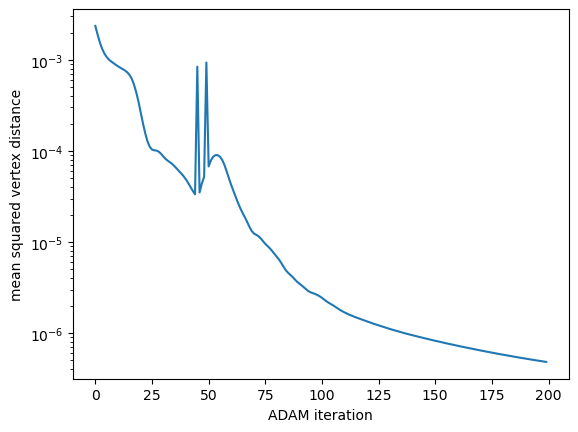

In [42]:
# ADAM loop. on this coarse mesh, each iteration (forward relaxation + implicit
# backward pass) takes a few milliseconds once compiled
value_and_grad = jax.jit(jax.value_and_grad(loss, has_aux=True))

optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(params)
history = []
for k in range(200):
    (L, fit), grads = value_and_grad(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    history.append(fit)

plt.semilogy(history)
plt.xlabel("ADAM iteration"); plt.ylabel("mean squared vertex distance");

In [43]:
# the recovered pattern reproduces the target shape to a fraction of a percent ...
v_recovered = relax_shell(*params, v0, hemesh, metric_rest, b_rest)
err = jnp.linalg.norm(kabsch_align(v_recovered, v_teacher)[0] - v_teacher, axis=-1)
print(f"max vertex error {err.max():.4f} vs target displacement scale {displacement.max():.3f}")

max vertex error 0.0019 vs target displacement scale 0.393


In [44]:
# plot the initial and final recovered shapes next to the teacher shape
p = meshplot.plot(np.array(v_recovered_initial), np.array(hemesh.faces), shading={"wireframe": True},
                  return_plot=True)

p.add_mesh(np.array(v_recovered) + np.array([2.5, 0, 0]), np.array(hemesh.faces), shading={"wireframe": True},)

p.add_mesh(np.array(v_teacher) + np.array([5, 0, 0]), np.array(hemesh.faces), shading={"wireframe": True})
p.save("tutorial_plots/06_teacher_vs_student.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0145729…

Plot saved to file tutorial_plots/06_teacher_vs_student.html.


In [ ]:
IFrame(src="tutorial_plots/06_teacher_vs_student.html", width="100%", height=400)

median director angle error: 24.0 deg


<>:8: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:8: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/vm/1jl6rjln6n9cjt54vsr9n4800000gr/T/ipykernel_32451/1643597439.py:8: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.xlabel(r"teacher angle $\theta^t$ (mod $\pi$)"); plt.ylabel("recovered angle (mod $\pi$)");


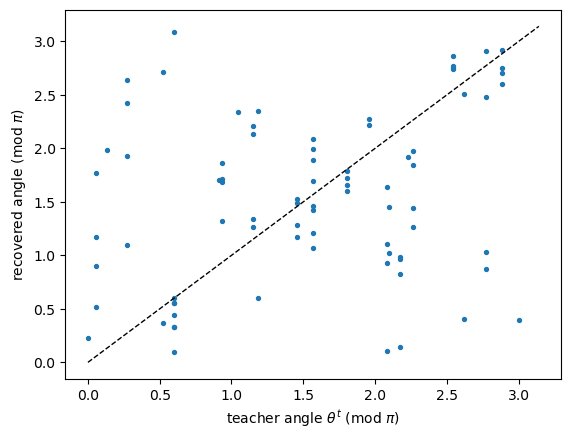

In [45]:
# Let's plot the recovered director field and the hidden teacher pattern

delta = (params[0] - theta_teacher_top + np.pi / 2) % np.pi - np.pi / 2
print(f"median director angle error: {np.degrees(np.median(np.abs(delta))):.1f} deg")

plt.scatter(theta_teacher_top % np.pi, params[0] % np.pi, s=8)
plt.plot([0, np.pi], [0, np.pi], "k--", lw=1)
plt.xlabel(r"teacher angle $\theta^t$ (mod $\pi$)"); plt.ylabel("recovered angle (mod $\pi$)");

The shape is reproduced almost exactly — but the *pattern* is only partially identified: the difference between teacher and student parameters is substantial.  The reason is that many patterns produce similar relaxed shapes. This non-uniqueness is a generic feature of inverse problems. Adding the smoothness regularizer selects *one* well-behaved solution (with smooth director fields) among the near-degenerate ones. But this is not necessarily the teacher pattern (you can check by `reg`).

### Inverse design 2: a hand-designed target

Now for a real design task: deform the sphere into a *prescribed* shape, in this case, an ellipsoid. Unlike the teacher target, an ellipsoid is generally **not exactly reachable**: the nematic actuation is locally area-preserving ($\det \Lambda = 1$) and the expansion ratio is fixed at $\lambda$, so the design space is constrained. Gradient descent will find the best compromise.

fit 6.18e-03 -> 5.66e-04, max vertex error 0.054 (target displacement scale 0.20)


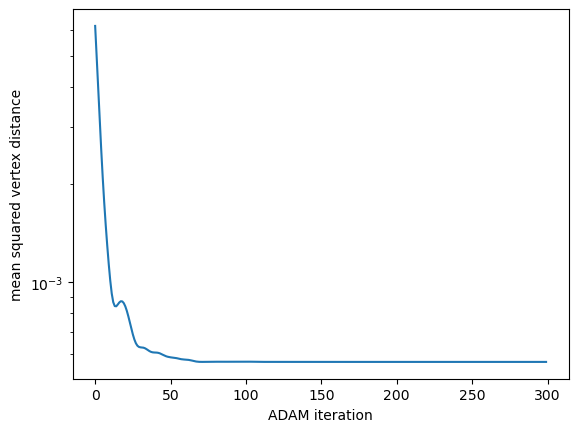

In [46]:
v_ellipsoid = v0 * jnp.array([0.95, 0.95, 1.2])

loss = make_loss(v_ellipsoid, v0, hemesh, metric_rest, b_rest, reg=1e-3)
value_and_grad = jax.jit(jax.value_and_grad(loss, has_aux=True))

params = (jnp.zeros(hemesh.n_faces), jnp.zeros(hemesh.n_faces))
optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(params)
history = []
for k in range(300):
    (L, fit), grads = value_and_grad(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    history.append(fit)

v_designed = relax_shell(*params, v0, hemesh, metric_rest, b_rest)
err = jnp.linalg.norm(kabsch_align(v_designed, v_ellipsoid)[0] - v_ellipsoid, axis=-1)
print(f"fit {history[0]:.2e} -> {history[-1]:.2e}, max vertex error {err.max():.3f} "
      f"(target displacement scale {jnp.linalg.norm(v_ellipsoid - v0, axis=-1).max():.2f})")

plt.semilogy(history)
plt.xlabel("ADAM iteration"); plt.ylabel("mean squared vertex distance");

In [47]:
# left: designed shape (colored by vertex error, with the optimized top director
# field); right: the ellipsoid target
p = meshplot.plot(np.array(v_designed), np.array(hemesh.faces), np.array(err),
                  shading={"wireframe": True}, return_plot=True)
p.add_lines(*director_segments(params[0], v_designed, hemesh), shading={"line_color": "red"})
p.add_mesh(np.array(v_ellipsoid) + np.array([2.5, 0, 0]), np.array(hemesh.faces),
           shading={"wireframe": True})
p.save("tutorial_plots/06_ellipsoid_design.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.002155…

Plot saved to file tutorial_plots/06_ellipsoid_design.html.


In [25]:
IFrame(src="tutorial_plots/06_ellipsoid_design.html", width="100%", height=400)

In [49]:
TriMesh.read_obj(f"tutorial_meshes/sphere.obj", dim=3).vertices.shape[0]

  o Icosphere


42

In [50]:
TriMesh.read_obj(f"tutorial_meshes/suzanne.obj", dim=3).vertices.shape[0]

  o Suzanne


507

### Scaling up

The same code runs on finer meshes, only slower. The inner elastic energy relaxation via BFGS dominates. On a 642-vertex sphere, one ADAM iteration takes on the order of a second, so the run below takes a few minutes.

For yet larger problems, consider (i) a limited-memory inner solver, (ii) warm-starting the relaxation from the previous outer iteration.

In [51]:
v0_fine, hemesh_fine = load_sphere("sphere_fine")
metric_rest_fine = elastic.get_metric(v0_fine, hemesh_fine)
b_rest_fine = elastic.get_second_fundamental_form(v0_fine, hemesh_fine)
v_target_fine = v0_fine * jnp.array([0.95, 0.95, 1.2])

loss = make_loss(v_target_fine, v0_fine, hemesh_fine, metric_rest_fine, b_rest_fine, reg=1e-3)
value_and_grad = jax.jit(jax.value_and_grad(loss, has_aux=True))

params = (jnp.zeros(hemesh_fine.n_faces), jnp.zeros(hemesh_fine.n_faces))
optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(params)
history_fine = []
for k in range(150):
    (L, fit), grads = value_and_grad(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    history_fine.append(fit)

v_designed_fine = relax_shell(*params, v0_fine, hemesh_fine, metric_rest_fine, b_rest_fine)
err_fine = jnp.linalg.norm(kabsch_align(v_designed_fine, v_target_fine)[0] - v_target_fine, axis=-1)
print(f"fit {history_fine[0]:.2e} -> {history_fine[-1]:.2e}, "
      f"max vertex error {err_fine.max():.3f}")

  o Icosphere


fit 5.94e-03 -> 5.27e-04, max vertex error 0.051


In [27]:
p = meshplot.plot(np.array(v_designed_fine), np.array(hemesh_fine.faces), np.array(err_fine),
                  shading={"wireframe": False}, return_plot=True)
p.add_lines(*director_segments(params[0], v_designed_fine, hemesh_fine, scale=0.05),
            shading={"line_color": "red"})
p.add_mesh(np.array(v_target_fine) + np.array([2.5, 0, 0]), np.array(hemesh_fine.faces),
           shading={"wireframe": False})
p.save("tutorial_plots/06_ellipsoid_design_fine.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0003274…

Plot saved to file tutorial_plots/06_ellipsoid_design_fine.html.


In [28]:
IFrame(src="tutorial_plots/06_ellipsoid_design_fine.html", width="100%", height=400)

### Suzanne

**Outlook.** To attack "Suzanne" from the introduction, two more ingredients are needed: a loss that compares meshes with *different* connectivity (e.g. the Chamfer distance, using the closest-point queries of the `interp` module), and care that the target is reachable — concave features are hard for a shell that must preserve local areas. We leave this as an (ambitious) exercise.